# 01 · EDA / 빈도 / 워드클라우드

빅카인즈 뉴스 전수(2025-06-01 ~ 2026-06-01, 20,521건)를 로드·정제하고
기본 통계 → 월별 추이 → 단어 빈도 → 워드클라우드를 살펴본다.

무거운 로직은 `src/preprocess.py`에 있고, 여기서는 import해서 분석/시각화만 한다.

In [1]:
# 셋업: 프로젝트 루트를 path에 추가하고 모듈 import + 한글 폰트 등록
import sys; sys.path.append("..")   # notebooks/ 기준 프로젝트 루트

from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

import config
from src import preprocess as pp

config.set_korean_font()   # 맑은고딕/나눔고딕 자동 탐지
print("폰트:", plt.rcParams["font.family"])

폰트: ['Malgun Gothic']


## 1. 데이터 로드 & 정제

`data/raw/*.xlsx`를 모두 읽어 식별자(str) 기준 병합·중복제거 → 제외플래그·완전중복 제거 → `날짜` 컬럼 추가.

In [2]:
df_raw = pp.load_raw()
print("원본(식별자 중복제거):", df_raw.shape)

df = pp.filter_documents(df_raw)
print("정제 후:", df.shape)
print("제거된 행:", len(df_raw) - len(df))
print("기간:", df["날짜"].min().date(), "~", df["날짜"].max().date())

df[["일자", "언론사", "제목"]].head()

C:\Users\compo\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


C:\Users\compo\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


원본(식별자 중복제거): (20521, 19)
정제 후: (20079, 20)
제거된 행: 442
기간: 2025-06-01 ~ 2026-06-01


,일자,언론사,제목
0,20251130,중도일보,"서산시 인지면 새마을남녀지도자협의회, '사랑의 김장 나눔'으로 사랑 전달"
1,20251130,YTN,"""나 혼자 살다 죽다""...고독사 늘고 고립은 심화"
2,20251130,YTN,'나혼자 산다' 36%...국민 5명 중 1명 노인
3,20251130,중도일보,"서산시, 2025년 찾아가는 보건복지 서비스 우수사례 시상식 개최"
4,20251130,중도일보,증평지역 기관 단체의 그침 없는 이웃 사랑 귀감


## 2. 기본 통계 — 언론사 분포

언론사 수: 103
언론사
부산일보      996
중도일보      995
브레이크뉴스    639
충청타임즈     635
뉴스핌       528
브릿지경제     514
충청일보      501
동양일보      457
헤럴드경제     441
아시아경제     435
대전일보      426
금강일보      421
충북일보      404
파이낸셜뉴스    368
메트로경제     343


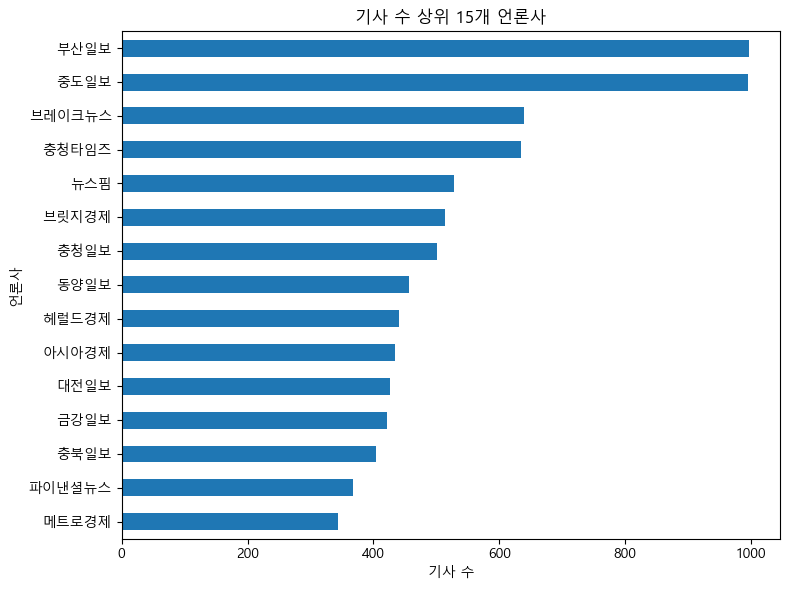

In [3]:
print("언론사 수:", df["언론사"].nunique())
top_press = df["언론사"].value_counts().head(15)
print(top_press.to_string())

fig, ax = plt.subplots(figsize=(8, 6))
top_press[::-1].plot.barh(ax=ax)
ax.set_title("기사 수 상위 15개 언론사")
ax.set_xlabel("기사 수")
fig.tight_layout()
fig.savefig(config.FIG_DIR / "01_top_press.png", dpi=150)
plt.show()

## 3. 월별 기사 추이

전체 1년 기간의 월별 기사량 변화. (마지막 2026-06은 6/1 하루치만 포함)

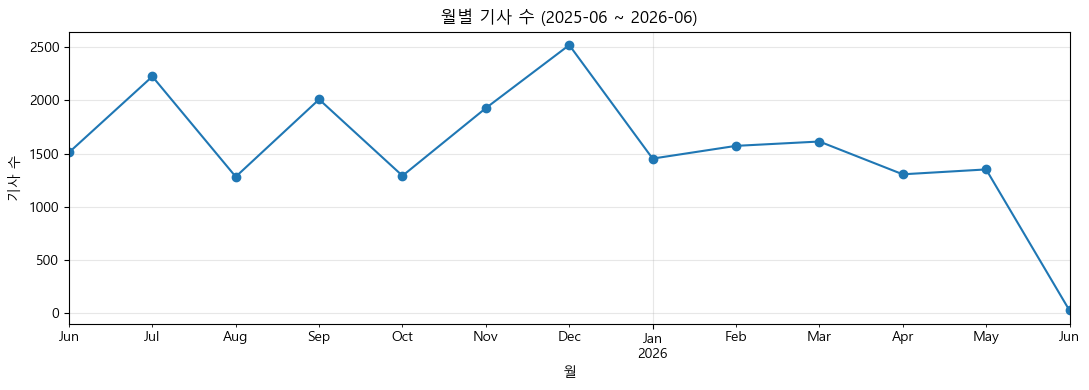

날짜
2025-06-30    1510
2025-07-31    2226
2025-08-31    1281
2025-09-30    2010
2025-10-31    1290
2025-11-30    1928
2025-12-31    2522
2026-01-31    1452
2026-02-28    1572
2026-03-31    1613
2026-04-30    1304
2026-05-31    1350
2026-06-30      21
Freq: ME, dtype: int64

In [4]:
monthly = df.set_index("날짜").resample("ME").size()

fig, ax = plt.subplots(figsize=(11, 4))
monthly.plot(marker="o", ax=ax)
ax.set_title("월별 기사 수 (2025-06 ~ 2026-06)")
ax.set_xlabel("월")
ax.set_ylabel("기사 수")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(config.FIG_DIR / "01_monthly_trend.png", dpi=150)
plt.show()

monthly

## 4. 토큰화 (Okt 명사추출)

`src/preprocess.py`로 본문에서 명사를 추출한다. 전수 토큰화는 약 1분 걸리므로,
한 번 만든 결과는 `data/processed/news_tokenized.pkl`에 캐시하고 이후엔 바로 로드한다.
복합어(`독거노인`, `고독사` 등)는 Okt가 쪼갠 조각을 다시 합쳐 한 토큰으로 보존한다.

In [5]:
CACHE = "news_tokenized"
try:
    df = pp.load_processed(CACHE)
    print("캐시 로드:", df.shape)
except FileNotFoundError:
    print("캐시 없음 → 토큰화 수행 (약 1분)...")
    df = pp.tokenize_dataframe(
        df, text_col="본문", out_col="nouns",
        compounds=tuple(config.KEYWORDS),
    )
    pp.save_processed(df, CACHE)
    print("저장 완료:", df.shape)

df["nouns"].head(3).tolist()

캐시 로드: (20079, 21)


[['서산시',
  '인지면',
  '새마을',
  '남녀',
  '지도자',
  '사랑',
  '김장',
  '모습',
  '서산시',
  '인지면',
  '새마을',
  '남녀',
  '지도자',
  '인지면',
  '행정',
  '복지',
  '센터',
  '공관',
  '사랑',
  '김장',
  '새마을',
  '회원',
  '자원봉사자',
  '인지면',
  '직원',
  '한겨울',
  '추위',
  '분위기',
  '김장'],
 ['앵커',
  '가구',
  '혼자',
  '죽음',
  '맞이',
  '고독사',
  '증가',
  '사망자',
  '고립',
  '상태',
  '점점',
  '정부',
  '위험',
  '조사',
  '대책',
  '남성은',
  '혼자',
  '처지',
  '사람',
  '소식'],
 ['앵커',
  '예능',
  '프로그램',
  '제목',
  '혼자',
  '가구',
  '계속',
  '출생',
  '고령화',
  '추세',
  '우리',
  '국민',
  '노인',
  '어린이집',
  '숫자',
  '급감',
  '광연',
  '보도',
  '외로움',
  '팔지',
  '혼자',
  '식사',
  '유튜브',
  '시청',
  '달라',
  '혼밥족',
  '거부',
  '식당']]

## 5. 단어 빈도 Top 30

총 토큰 수: 645829 | 고유 단어 수: 22461


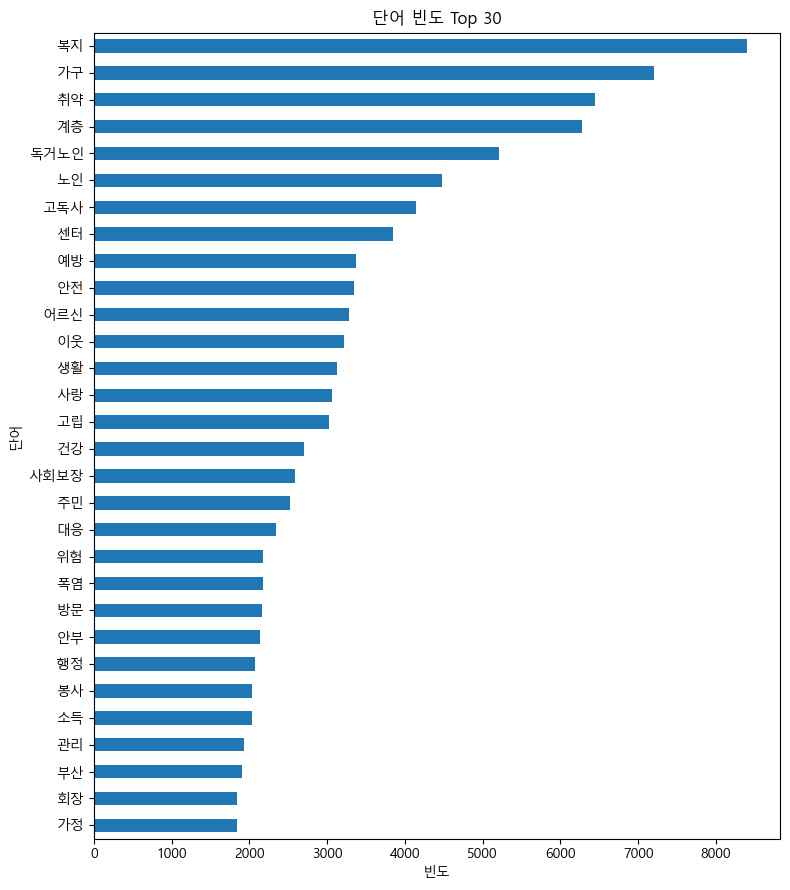

,단어,빈도
0,복지,8404
1,가구,7209
2,취약,6444
3,계층,6276
4,독거노인,5210
5,노인,4471
6,고독사,4137
7,센터,3847
8,예방,3372
9,안전,3344


In [6]:
all_nouns = [w for lst in df["nouns"] for w in lst]
cnt = Counter(all_nouns)
print("총 토큰 수:", len(all_nouns), "| 고유 단어 수:", len(cnt))

top_n = 30
top_words = cnt.most_common(top_n)
freq_df = pd.DataFrame(top_words, columns=["단어", "빈도"])

# 표 저장
config.TABLE_DIR.mkdir(parents=True, exist_ok=True)
freq_df.to_csv(config.TABLE_DIR / "01_word_freq_top30.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(8, 9))
freq_df.set_index("단어")["빈도"][::-1].plot.barh(ax=ax)
ax.set_title(f"단어 빈도 Top {top_n}")
ax.set_xlabel("빈도")
fig.tight_layout()
fig.savefig(config.FIG_DIR / "01_word_freq_top30.png", dpi=150)
plt.show()

freq_df

## 6. 워드클라우드

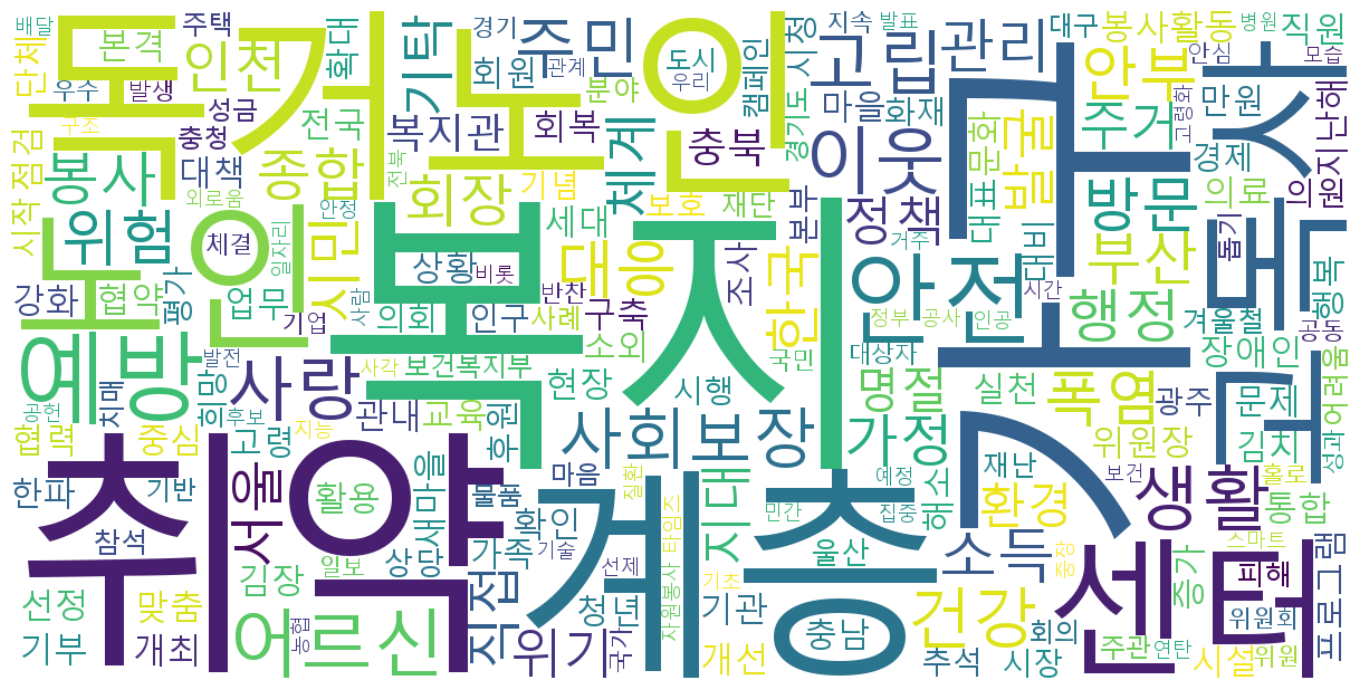

In [7]:
from wordcloud import WordCloud

wc = WordCloud(
    font_path=config.get_font_path(),
    width=1200, height=600,
    background_color="white",
    max_words=200,
).generate_from_frequencies(dict(cnt.most_common(200)))

config.FIG_DIR.mkdir(parents=True, exist_ok=True)
wc.to_file(str(config.FIG_DIR / "01_wordcloud.png"))

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
fig.tight_layout()
plt.show()

## 7. 메모 — 불용어 튜닝

빈도 상위에 `지역·사회·복지·사업·지원·취약·계층·나눔·전달·대상·협의·추진` 등
복지 보도자료의 행정 상투어가 다수 보인다. 주제를 더 선명하게 보려면
이런 단어를 `config.STOP_WORDS`에 추가한 뒤 토큰화 캐시를 다시 만들면 된다.

```python
# config.py
STOP_WORDS = ["지역", "사회", "사업", "추진", "협의", "대상", ...]
```
재생성: `data/processed/news_tokenized.pkl` 삭제 후 셀 4 다시 실행.